# Análise de Eficiência Temporal: Média de Vendas vs. Ociosidade (Questão 6)

O objetivo aqui é corrigir o erro do "estagiário". Vamos calcular a média real de vendas por dia da semana, levando em conta os dias em que a loja não vendeu nada, usando uma Dimensão Calendário.

---

### Preparação dos Dados e Datas

In [1]:
import pandas as pd
import duckdb
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.utils.data_loader import load_datasets

dfs = load_datasets(["vendas_2023_2024.csv"], layer="raw")
df_sales = dfs["vendas_2023_2024.csv"]

df_sales["sale_date"] = pd.to_datetime(df_sales["sale_date"], format="mixed", dayfirst=True).dt.date

### Criação do Calendário e Cálculo da Média Real (SQL)
Através de uma CTE Recursiva geramos todos os dias do ano (de janeiro a dezembro). Depois, realizamos um `LEFT JOIN` com as vendas. 

Onde não há venda, o SQL coloca 0. Isto traz a média para a realidade e mostra que o Domingo não é tão produtivo quanto parecia.

In [2]:
pd.options.display.float_format = 'R$ {:,.2f}'.format

query_least_profit_days = """
WITH RECURSIVE calendar AS (
    SELECT
        (SELECT MIN(sale_date)::DATE FROM df_sales) as dim_date,
        (SELECT MAX(sale_date)::DATE FROM df_sales) as end_date

    UNION ALL

    SELECT
        (dim_date + INTERVAL '1 day')::DATE AS dim_date,
        end_date
    FROM calendar
    WHERE dim_date < end_date
),
calendar_with_dow AS (
    SELECT
        dim_date,
        CASE DAYOFWEEK(dim_date)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-Feira'
            WHEN 2 THEN 'Terça-Feira'
            WHEN 3 THEN 'Quarta-Feira'
            WHEN 4 THEN 'Quinta-Feira'
            WHEN 5 THEN 'Sexta-Feira'
            WHEN 6 THEN 'Sábado'
        END AS day_name_pt
    FROM calendar
),
daily_sales AS (
    SELECT
        sale_date,
        SUM(total) AS daily_revenue,
    FROM df_sales
    GROUP BY sale_date
),
calendar_joined AS (
    SELECT
        c.dim_date,
        c.day_name_pt,
        COALESCE(ds.daily_revenue, 0) AS final_daily_revenue
    FROM calendar_with_dow c
    LEFT JOIN daily_sales ds
        ON c.dim_date = ds.sale_date
)
SELECT 
    day_name_pt,
    AVG(final_daily_revenue) AS true_average_sales
FROM calendar_joined
GROUP BY day_name_pt
ORDER BY true_average_sales ASC;
"""

df_calendar_sales = duckdb.query(query_least_profit_days).df()

worst_day = df_calendar_sales.iloc[0]

print("=" * 51)
print(f"O dia da semana com a PIOR média histórica de vendas é o: {worst_day['day_name_pt'].upper()}")
print(f"Média diária real (considerando dias zerados): R$ {worst_day['true_average_sales']:,.2f}")
print("=" * 51, "\n")

df_presentation = df_calendar_sales.rename(columns={
    'day_name_pt': 'Dia da Semana',
    'true_average_sales': 'Média Histórica de Vendas (R$)'
})

print("Ranking Completo:")
print(df_presentation.to_string(index=False))

O dia da semana com a PIOR média histórica de vendas é o: DOMINGO
Média diária real (considerando dias zerados): R$ 3,229,614.16

Ranking Completo:
Dia da Semana  Média Histórica de Vendas (R$)
      Domingo                 R$ 3,229,614.16
Segunda-Feira                 R$ 3,484,500.47
  Terça-Feira                 R$ 3,488,871.99
 Quarta-Feira                 R$ 3,534,007.21
 Quinta-Feira                 R$ 3,713,299.94
       Sábado                 R$ 3,774,290.79
  Sexta-Feira                 R$ 3,776,151.25


### Visualização: Média de Vendas vs. Dias Sem Venda

Montamos um gráfico de eixos duplos. As barras mostram o faturamente por dia, e a linha mostra a "Taxa de Ociosidade" (quantos desses dias ficaram sem realizar vendas).

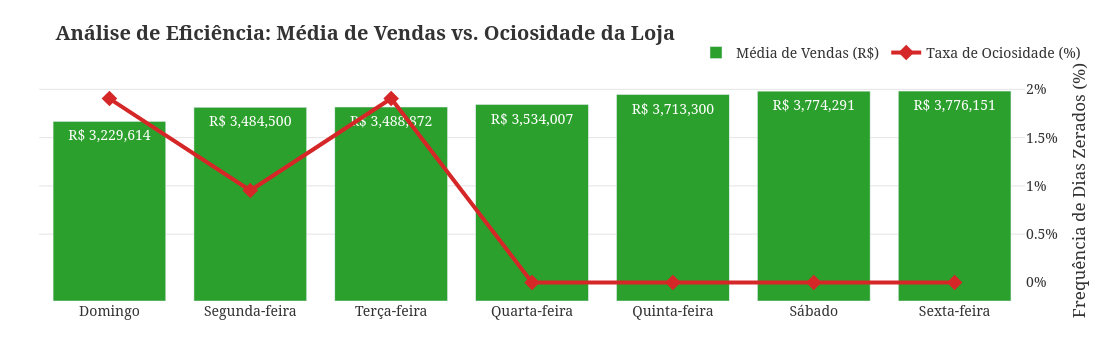


DIAGNÓSTICO:

>> O Domingo e a Terça-feira são os dias de maior risco operacional,
   apresentando os maiores índices de ociosidade (dias sem venda).

---------------------------------------------------------------------------
ANÁLISE DE IMPACTO:
A média de vendas de Domingo era 'artificial', pois ignorava os diversos
   dias em que a loja operou com faturamento zero.



In [13]:
# ==========================================
# DATA PROCESSING
# ==========================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

query_idle_rate = """
WITH RECURSIVE calendar AS (
    SELECT
        (SELECT MIN(sale_date)::DATE FROM df_sales) as dim_date,
        (SELECT MAX(sale_date)::DATE FROM df_sales) as end_date
    UNION ALL
    SELECT
        (dim_date + INTERVAL '1 day')::DATE AS dim_date,
        end_date
    FROM calendar
    WHERE dim_date < end_date
),
calendar_with_dow AS (
    SELECT
        dim_date,
        CASE DAYOFWEEK(dim_date)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS day_name_pt
    FROM calendar
),
daily_sales AS (
    SELECT
        sale_date,
        SUM(total) AS daily_revenue
    FROM df_sales
    GROUP BY sale_date
),
calendar_joined AS (
    SELECT
        c.dim_date,
        c.day_name_pt,
        COALESCE(ds.daily_revenue, 0) AS final_daily_revenue,
        CASE WHEN ds.daily_revenue IS NULL THEN 1 ELSE 0 END AS is_idle
    FROM calendar_with_dow c
    LEFT JOIN daily_sales ds
        ON c.dim_date = ds.sale_date
)
SELECT 
    day_name_pt,
    AVG(final_daily_revenue) AS true_average_sales,
    (SUM(is_idle) * 100.0) / COUNT(dim_date) AS idle_rate_pct
FROM calendar_joined
GROUP BY day_name_pt
ORDER BY true_average_sales ASC;
"""

df_idle = duckdb.query(query_idle_rate).df()

# ==========================================
# VISUALIZATION
# ==========================================

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=df_idle['day_name_pt'],
        y=df_idle['true_average_sales'],
        name="Média de Vendas (R$)",
        marker_color='#2ca02c',
        text=df_idle['true_average_sales'],
        texttemplate='R$ %{text:,.0f}',
        textposition='inside',
        insidetextanchor='end',
        hovertemplate="<b>%{x}</b><br>Média: R$ %{y:,.2f}<extra></extra>"
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=df_idle['day_name_pt'],
        y=df_idle['idle_rate_pct'],
        name="Taxa de Ociosidade (%)",
        mode='lines+markers',
        line=dict(color='#d62728', width=4),
        marker=dict(size=12, symbol='diamond'),
        hovertemplate="<b>%{x}</b><br>Dias sem venda: %{y:.1f}%<extra></extra>"
    ),
    secondary_y=True,
)

fig.update_layout(
    title='<b>Análise de Eficiência: Média de Vendas vs. Ociosidade da Loja</b>',
    plot_bgcolor="white",
    font=dict(family="Arial", size=14, color="#333333"),
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="right", x=1),
    margin=dict(t=80, l=20, r=20, b=20)
)

fig.update_yaxes(title_text="", showticklabels=False, showgrid=False, secondary_y=False)
fig.update_yaxes(title_text="Frequência de Dias Zerados (%)", showgrid=True, gridcolor="#e5e5e5", ticksuffix="%", secondary_y=True)
fig.update_xaxes(title="")

fig.show()

# ==========================================
# DIAGNOSE
# ==========================================

print("\n" + "="*75)
print("DIAGNÓSTICO:")
print("="*75 + "\n")
print(">> O Domingo e a Terça-feira são os dias de maior risco operacional,")
print("   apresentando os maiores índices de ociosidade (dias sem venda).\n")

print("-" * 75)
print("ANÁLISE DE IMPACTO:")
print("A média de vendas de Domingo era 'artificial', pois ignorava os diversos")
print("   dias em que a loja operou com faturamento zero.")
print("="*75 + "\n")

### Mapa de Calor: Sazonalidade de Conversão

Identificar se a baixa performance de dias como terça-feira e domingo é constante ou se existem meses específicos onde o comportamento muda. Isso ajuda o comercial a planejar promoções nos "buracos" de venda e o setor de operações a saber quando a loja terá menos movimento para realizar manutenções ou inventários.

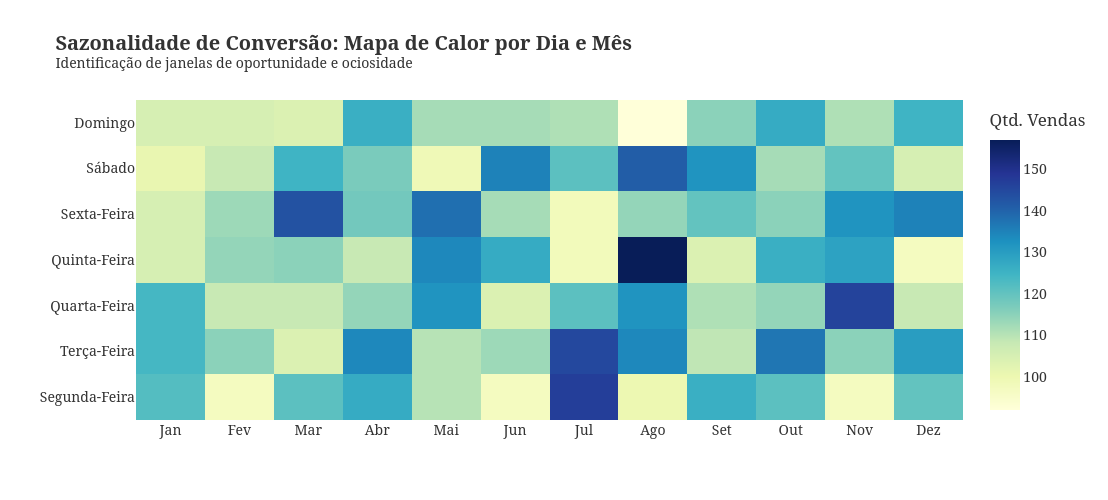


 DIAGNÓSTICO 

INSIGHT PRINCIPAL:
>> O maior volume de conversão ocorre historicamente aos meses de pico,
   especialmente no mês 8 (Ago).

ESTRATÉGIA SUGERIDA:
>> Utilizar os 'buracos' (áreas claras no mapa) para campanhas de ativação
específicas, focando em converter a ociosidade das terças e domingos.



In [12]:
import duckdb
import plotly.graph_objects as go

# ==========================================
# DATA PROCESSING
# ==========================================

query_heatmap = """
-- Table names clarification:
-- df_sales: Represents sales_2023_2024.csv.

SELECT 
    month(sale_date) AS month_idx,
    CASE dayofweek(sale_date)
        WHEN 0 THEN '7. Domingo'
        WHEN 1 THEN '1. Segunda-Feira'
        WHEN 2 THEN '2. Terça-Feira'
        WHEN 3 THEN '3. Quarta-Feira'
        WHEN 4 THEN '4. Quinta-Feira'
        WHEN 5 THEN '5. Sexta-Feira'
        WHEN 6 THEN '6. Sábado'
    END AS day_name,
    COUNT(id) AS sales_count
FROM df_sales
GROUP BY 1, 2
ORDER BY 1, 2
"""

df_heatmap_raw = duckdb.query(query_heatmap).df()
df_pivot = df_heatmap_raw.pivot(index='day_name', columns='month_idx', values='sales_count').fillna(0)

months_pt = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}
display_months = [months_pt[m] for m in df_pivot.columns]
display_days = [d.split('. ')[1] for d in df_pivot.index]

# ==========================================
# VISUALIZATION
# ==========================================

fig = go.Figure(data=go.Heatmap(
    z=df_pivot.values,
    x=display_months,
    y=display_days,
    colorscale='YlGnBu',
    showscale=True,
    colorbar=dict(title="Qtd. Vendas"),
    hovertemplate="<b>%{y}</b> em <b>%{x}</b><br>Total de Vendas: %{z}<extra></extra>"
))

fig.update_layout(
    title='<b>Sazonalidade de Conversão: Mapa de Calor por Dia e Mês</b><br><sup>Identificação de janelas de oportunidade e ociosidade</sup>',
    xaxis_title="",
    yaxis_title="",
    font=dict(family="Arial", size=14, color="#333333"),
    width=900,
    height=500,
    plot_bgcolor='white'
)

fig.show()

# ==========================================
# DIAGNOSE
# ==========================================

print("\n" + "="*75)
print(" DIAGNÓSTICO ")
print("="*75 + "\n")

if not df_heatmap_raw.empty:
    peak = df_heatmap_raw.loc[df_heatmap_raw['sales_count'].idxmax()]
    print(f"INSIGHT PRINCIPAL:")
    print(f">> O maior volume de conversão ocorre historicamente aos meses de pico,")
    print(f"   especialmente no mês {peak['month_idx']} ({months_pt[peak['month_idx']]}).")
    print(f"\nESTRATÉGIA SUGERIDA:")
    print(">> Utilizar os 'buracos' (áreas claras no mapa) para campanhas de ativação")
    print("específicas, focando em converter a ociosidade das terças e domingos.")
    print("="*75 + "\n")

### Questão 6.3 - Interpretação

**Por que é necessário utilizar uma tabela de datas (calendário) em vez de agrupar diretamente a tabela de vendas?**

Ao agrupar diretamente a tabela de vendas (`GROUP BY sale_date`), o motor SQL só considera os dias em que houve pelo menos uma transação registrada. Se a loja abriu numa terça-feira e não vendeu absolutamente nada, essa data simplesmente "não existe" na tabela de fatos. A dimensão de calendário cria um esqueleto contínuo e ininterrupto de tempo, garantindo que o `LEFT JOIN` exponha esses buracos e force o registro de uma receita de R$ 0,00 para os dias de "venda zero".

**O que aconteceria com a média de vendas se um dia da semana tivesse muitos dias sem nenhuma venda registrada?**

Se usarmos a abordagem errada do estagiário (sem calendário), a média matemática ignora os dias zerados. Por exemplo: se num mês tivemos 4 terças-feiras, mas a loja só vendeu `R$ 10.000,00` em apenas uma delas (e zero nas outras três), o cálculo do estagiário diria que a média das terças-feiras é `R$ 10.000,00` (pois ele divide por 1). Com o calendário, os dias zerados entram na conta, e a média real será de `R$ 2.500,00` (10.000 dividido por 4 dias reais). Ignorar o calendário infla artificialmente os resultados e oculta a ociosidade da operação.